In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
from transformers import BertTokenizer
from dynamic_dataloader import CustomDataLoader
import math

np.random.seed(42)

/Users/mahas/PycharmProjects/STIRS/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Setting up Parameters and Loading Data

In [2]:
# Setting up the parameters
maximum_features = 30522  # Vocabulary size for BERT
maximum_length = 128  # Max length of input sequences
word_embedding_dims = 50  # Dimension of word embeddings (Note: In PyTorch this is embedding_dim)
no_of_filters = 128  # Number of filters for Conv1D
kernel_size = 3  # Size of the convolutional kernel
hidden_dim_1 = 128  # Neurons in the dense hidden layer

gamma = 0.2

batch_size = 64
epochs = 10
threshold = 0.5
DATASET_SIZE = 100_000

# Load and preprocess the dataset
# Make sure the path to your CSV is correct
df = pd.read_csv("../jigsaw/dataset_text_target.csv").dropna()
df_true = df[df.target > 0.5]
df_false = df[df.target <= 0.5]
df = pd.concat([df_true[:DATASET_SIZE // 2], df_false[:DATASET_SIZE // 2]], axis=0)
# mapper = lambda x: 1 if x > 0.5 else 0
# df['target'] = df['target'].apply(mapper)

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    df.comment_text, df.target, test_size=0.2, random_state=42, shuffle=True
)

<Axes: >

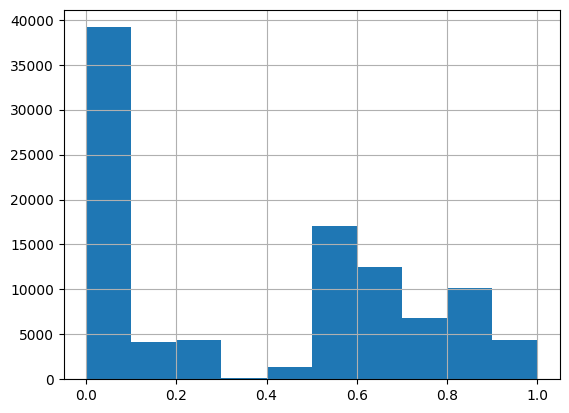

In [3]:
df['target'].hist()

### 3. Tokenization and Data Preparation
Here, we tokenize the text with the BERT tokenizer but set `return_tensors='pt'` for PyTorch tensors. We then create `TensorDataset` and `DataLoader` objects to handle batching.

In [4]:
# Tokenize and encode the data using the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Encode the training and test data
X_train_encoded = tokenizer.batch_encode_plus(
    x_train.tolist(),
    padding='max_length',
    truncation=True,
    max_length=maximum_length,
    add_special_tokens=True,
    return_tensors='pt',  # Return PyTorch tensors
)

X_test_encoded = tokenizer.batch_encode_plus(
    x_test.tolist(),
    padding='max_length',
    truncation=True,
    max_length=maximum_length,
    add_special_tokens=True,
    return_tensors='pt',  # Return PyTorch tensors
)

# Create PyTorch Datasets
train_dataset = TensorDataset(X_train_encoded['input_ids'], torch.tensor(y_train.values, dtype=torch.float32))
test_dataset = TensorDataset(X_test_encoded['input_ids'], torch.tensor(y_test.values, dtype=torch.float32))

# Create DataLoaders
train_loader = CustomDataLoader(train_dataset, batch_size=batch_size, gamma=gamma)
test_loader = CustomDataLoader(test_dataset, batch_size=batch_size, gamma=gamma)

In [5]:
train_list = x_train.tolist()
test_list = x_test.tolist()

In [6]:
X_train_encoded["input_ids"].shape

torch.Size([80000, 128])

In [7]:
token_mapping = {}
for i, row in enumerate(X_train_encoded["input_ids"]):
    r = tuple(row.tolist())
    token_mapping[r] = train_list[i]
for i, row in enumerate(X_test_encoded["input_ids"]):
    r = tuple(row.tolist())
    token_mapping[r] = test_list[i]

In [8]:
len(list(token_mapping.keys())[0])

128

### 4. Building the PyTorch Model

We define the CNN architecture as a class inheriting from `torch.nn.Module`. Note the use of `.permute(0, 2, 1)` to make the tensor shape compatible with `nn.Conv1d`.

In [9]:
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_size, hidden_dim):
        super(CNNTextClassifier, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Convolutional layers
        self.conv1 = nn.Conv1d(embedding_dim, n_filters, kernel_size=filter_size, padding='valid')
        self.pool1 = nn.MaxPool1d(kernel_size=3)

        self.conv2 = nn.Conv1d(n_filters, n_filters, kernel_size=filter_size, padding='valid')
        self.pool2 = nn.MaxPool1d(kernel_size=3)

        self.conv3 = nn.Conv1d(n_filters, n_filters, kernel_size=filter_size, padding='valid')
        # Global Max Pooling is achieved with AdaptiveMaxPool1d
        self.global_pool = nn.AdaptiveMaxPool1d(1)

        # Dense layers
        self.fc1 = nn.Linear(n_filters, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        # input_ids shape: (batch_size, seq_len)
        embedded = self.embedding(input_ids)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        # PyTorch Conv1d expects (batch_size, channels, seq_len)
        # So we permute the dimensions
        embedded = embedded.permute(0, 2, 1)

        x = self.pool1(F.relu(self.conv1(embedded)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))

        x = self.global_pool(x).squeeze(2)  # Squeeze to remove the last dimension

        x = F.relu(self.fc1(x))
        output = torch.sigmoid(self.fc2(x))

        return output


# Instantiate the model
model = CNNTextClassifier(
    vocab_size=maximum_features,
    embedding_dim=word_embedding_dims,
    n_filters=no_of_filters,
    filter_size=kernel_size,
    hidden_dim=hidden_dim_1
)

# Set device (use GPU if available)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model.to(device)

CNNTextClassifier(
  (embedding): Embedding(30522, 50)
  (conv1): Conv1d(50, 128, kernel_size=(3,), stride=(1,), padding=valid)
  (pool1): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=valid)
  (pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=valid)
  (global_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

### 5. Training the Model

We define the loss function and optimizer, then write an explicit loop to train the model over 10 epochs and validate its performance.

In [10]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters())

# To store history
history = {
    'loss': [],
    'val_loss': [],
    'mse': [],
    'val_mse': []
}

best_val_loss = float('inf')
best_val_mse = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    total_loss = 0



    dynamic = True if epoch % 2 != 0 else False
    # print("Dynamic:", dynamic)
    times = 1
    if dynamic:
        times = math.ceil(1 / gamma)
    # print("Running", times, "times in this epoch")
    for _ in range(times):
        # do this batch loop how many ever times it needs
        # this will run 5 times, if its an even epoch, and gamma = 0.2
        batch_losses = {}
        for batch_id, (input_ids, labels) in train_loader.generate(dynamic=dynamic):
            # print(batch_id)
            input_ids, labels = input_ids.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)

            batch_losses[batch_id] = loss.item()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        train_loader.update_losses(batch_losses)

    avg_train_mse = total_loss / len(train_loader)

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_id, (input_ids, labels) in test_loader.generate():
            input_ids, labels = input_ids.to(device), labels.to(device).unsqueeze(1)
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

    avg_val_mse = total_val_loss / len(test_loader)

    # Save history
    history['loss'].append(avg_train_mse)
    history['val_loss'].append(avg_val_mse)
    history['mse'].append(avg_train_mse)
    history['val_mse'].append(avg_val_mse)

    # Save the best model
    if avg_val_mse < best_val_mse:
        best_val_mse = avg_val_mse
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"{'Dyn' if dynamic else 'Nor'} Epoch {epoch + 1}/{epochs} | "
          f"Train MSE: {avg_train_mse:.4f} | Val MSE: {avg_val_mse:.4f}")

# Load best model weights
model.load_state_dict(best_model_wts)

Nor Epoch 1/10 | Train MSE: 0.0720 | Val MSE: 0.0474
Dyn Epoch 2/10 | Train MSE: 0.0400 | Val MSE: 0.0360
Nor Epoch 3/10 | Train MSE: 0.0290 | Val MSE: 0.0387
Dyn Epoch 4/10 | Train MSE: 0.0275 | Val MSE: 0.0397
Nor Epoch 5/10 | Train MSE: 0.0219 | Val MSE: 0.0366
Dyn Epoch 6/10 | Train MSE: 0.0203 | Val MSE: 0.0365
Nor Epoch 7/10 | Train MSE: 0.0175 | Val MSE: 0.0375
Dyn Epoch 8/10 | Train MSE: 0.0164 | Val MSE: 0.0366
Nor Epoch 9/10 | Train MSE: 0.0147 | Val MSE: 0.0408
Dyn Epoch 10/10 | Train MSE: 0.0140 | Val MSE: 0.0366


<All keys matched successfully>

### 6. Evaluating the Model

In [11]:
model.eval()
# Compute Test MSE
mse_criterion = nn.MSELoss(reduction='mean')

total_test_loss = 0.0
n_test_batches = 0
with torch.no_grad():
    for batch_id, (input_ids, labels) in test_loader.generate():
        input_ids, labels = input_ids.to(device), labels.to(device).unsqueeze(1)
        outputs = model(input_ids)
        loss = mse_criterion(outputs, labels)
        total_test_loss += loss.item()
        n_test_batches += 1

test_mse = total_test_loss / max(1, n_test_batches)
print('\nEvaluation Metric:')
print('Test MSE:', test_mse)


Evaluation Metric:
Test MSE: 0.03603610438934435


### 7. Plotting Results

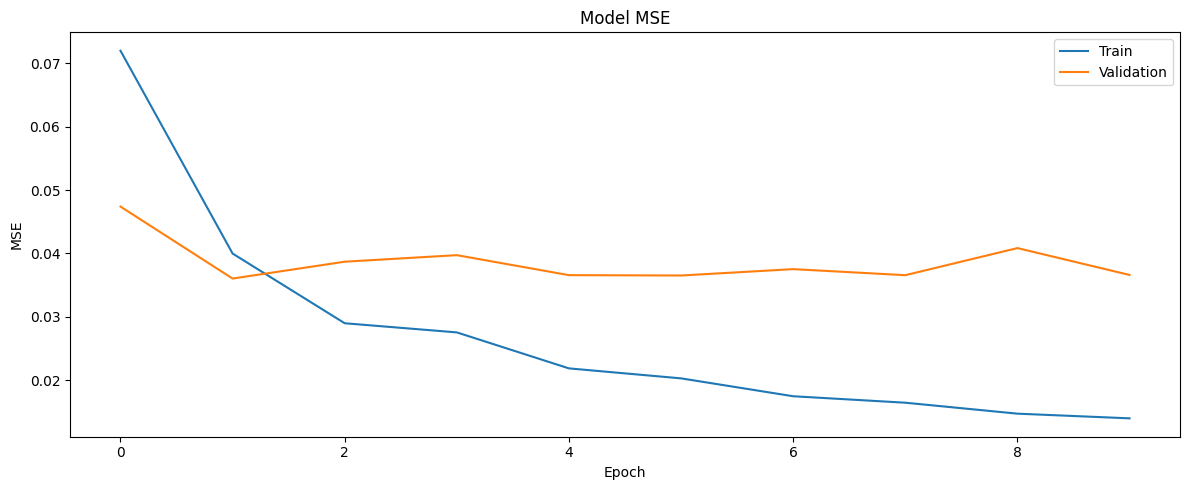

In [12]:
# Plotting Model MSE and Loss
plt.figure(figsize=(12, 5))

# MSE curves
plt.plot(history["mse"])
plt.plot(history["val_mse"])
plt.title("Model MSE")
plt.ylabel("MSE")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper right")

plt.tight_layout()
plt.show()

### 8. Saving the Model

Finally, we can save the trained model's state dictionary for later use.

In [13]:
dic = train_loader.get_batch_counts()
keys = list(dic.keys())
keys.sort(key=lambda x: dic[x], reverse=True)
print("Most Frequent Keys:")
for i in keys[:5]:
    print(i, dic[i])
print("Least Frequent Keys:")
for i in keys[-5:]:
    print(i, dic[i])

Most Frequent Keys:
49152 28
37312 26
38464 26
72192 26
72640 25
Least Frequent Keys:
77888 5
79296 5
79424 5
79488 5
79872 5


(array([315., 349., 241., 220.,  56.,  31.,  26.,   4.,   4.,   4.]),
 array([ 5. ,  7.3,  9.6, 11.9, 14.2, 16.5, 18.8, 21.1, 23.4, 25.7, 28. ]),
 <BarContainer object of 10 artists>)

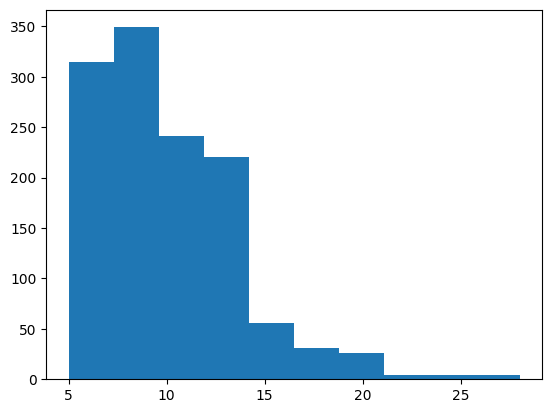

In [14]:
values = list(dic.values())
plt.hist(values)

In [15]:
len(batch)

NameError: name 'batch' is not defined

In [1]:
for batch_i in range(min(5, len(keys))):
    batch = train_loader._batches[keys[batch_i]]
    error = False
    for i, item in enumerate(batch[0]):
        it = tuple(item.tolist())
        print(token_mapping[it], f"[{batch[1][i]:.2f}]")
        print("="*20)

NameError: name 'keys' is not defined

In [36]:
for batch_i in range(-1, -min(5, len(keys)), -1):
    batch = train_loader._batches[keys[batch_i]]
    error = False
    for i, item in enumerate(batch[0]):
        it = tuple(item.tolist())
        print(token_mapping[it], f"[{batch[1][i]:.2f}]")
        print("="*20)

Theocrats gonna theocratize... [0.00]
No-no!  Not a waste of money!  Why they managed to shuffle a bunch the state doesn't have into corporations based in Washington DC.  What could possibly be a waste there?  They've done it a dozen or more times in the past, why stop now? [0.00]
your dog apparently had a track record of aggressiveness. true or not? if true he should not have been off leash [0.00]
REALLY good one! I have chills! [0.00]
Looks to me like they're more pissed off that a woman who's not the leader, not the Prime Minister, and not in Government took a free holiday, than that the Prime Minister outright violated the law in accepting his holiday from a billionaire who gets millions of dollars of government business.   Your outrage stinks. [0.60]
Pebble plans an open pit mine the size of the Grand Canyon, in the midst of the largest remaining wild salmon system on the planet. No one "loves" open pit mines - but at least the difference in scale and the current lead-time permits